In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, accuracy_score

sns.set_theme(style="darkgrid")
%matplotlib inline

In [3]:
df = pd.read_csv("../data/games_features.csv")
df.columns = df.columns.str.strip()
print(f"Total matchups: {len(df)}")
print(f"Seasons: {sorted(df['HOME_SEASON'].unique())}")
df.head(3)

Total matchups: 16369
Seasons: ['2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


,HOME_SEASON_ID,HOME_TEAM_ID,HOME_TEAM_ABBREVIATION,HOME_TEAM_NAME,GAME_ID,GAME_DATE,HOME_MATCHUP,HOME_WL,HOME_MIN,HOME_PTS,...,AWAY_EFG_PCT_ROLL10,AWAY_TOV_PCT_ROLL10,AWAY_FT_PCT_ROLL10,AWAY_PTS_ROLL10,AWAY_OREB_ROLL10,AWAY_DREB_ROLL10,AWAY_STL_ROLL10,AWAY_BLK_ROLL10,AWAY_PLUS_MINUS_ROLL10,TARGET
0,12015,12325,FLA,Flamengo Flamengo,11500069,2015-10-17,FLA vs. ORL,L,240,73,...,0.485737,0.148149,0.7358,97.400000,11.700000,32.5,9.1,4.200000,-2.200000,0
1,12014,1610612737,ATL,Atlanta Hawks,11400077,2014-10-18,ATL vs. DET,L,240,100,...,0.464775,0.157421,0.6446,97.000000,11.400000,34.4,8.6,4.800000,4.400000,0
2,12014,1610612737,ATL,Atlanta Hawks,11400089,2014-10-20,ATL vs. CHA,W,264,117,...,0.447761,0.123304,0.7940,94.333333,9.833333,34.5,6.0,4.666667,-2.333333,1


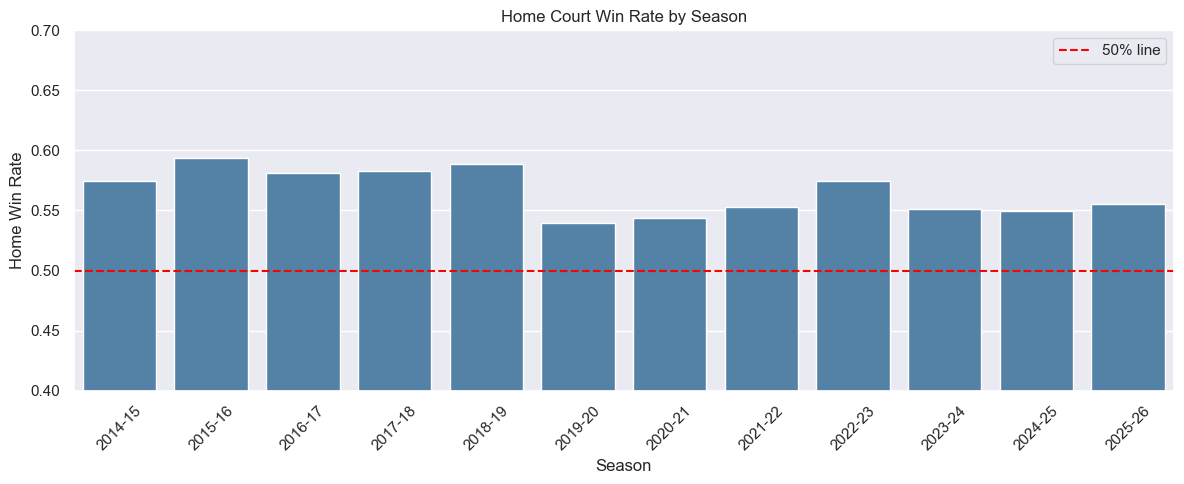

In [4]:
home_wr = df.groupby("HOME_SEASON")["TARGET"].mean().reset_index()
home_wr.columns = ["Season", "Home Win Rate"]

plt.figure(figsize=(12, 5))
sns.barplot(data=home_wr, x="Season", y="Home Win Rate", color="steelblue")
plt.axhline(0.5, color="red", linestyle="--", label="50% line")
plt.title("Home Court Win Rate by Season")
plt.xticks(rotation=45)
plt.ylim(0.4, 0.7)
plt.legend()
plt.tight_layout()
plt.show()

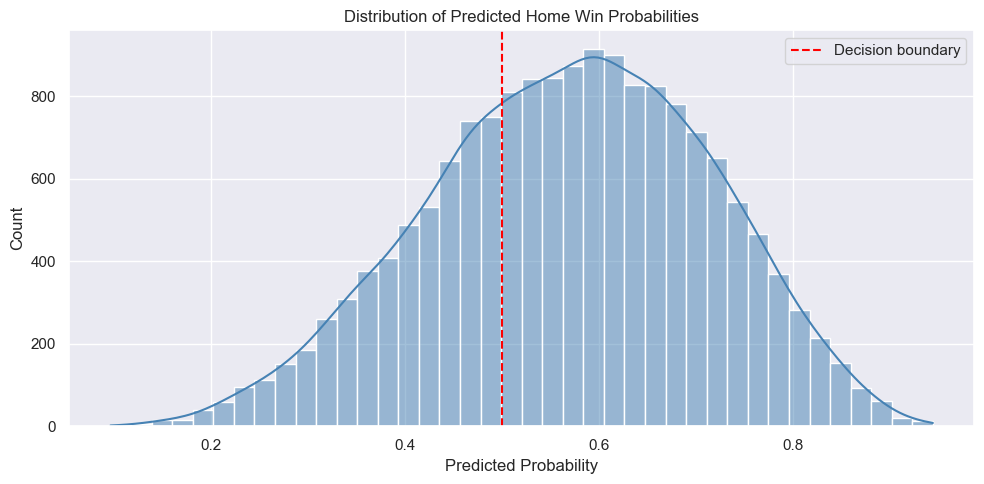

In [5]:
model  = joblib.load("../models/logreg_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

FEATURE_COLS = [
    "HOME_OFF_RTG_ROLL10",  "AWAY_OFF_RTG_ROLL10",
    "HOME_EFG_PCT_ROLL10",  "AWAY_EFG_PCT_ROLL10",
    "HOME_TOV_PCT_ROLL10",  "AWAY_TOV_PCT_ROLL10",
    "HOME_FT_PCT_ROLL10",   "AWAY_FT_PCT_ROLL10",
    "HOME_PTS_ROLL10",      "AWAY_PTS_ROLL10",
    "HOME_OREB_ROLL10",     "AWAY_OREB_ROLL10",
    "HOME_DREB_ROLL10",     "AWAY_DREB_ROLL10",
    "HOME_STL_ROLL10",      "AWAY_STL_ROLL10",
    "HOME_BLK_ROLL10",      "AWAY_BLK_ROLL10",
    "HOME_PLUS_MINUS_ROLL10","AWAY_PLUS_MINUS_ROLL10",
]

X = df[FEATURE_COLS].dropna()
y = df.loc[X.index, "TARGET"]
X_scaled = scaler.transform(X)
probs = model.predict_proba(X_scaled)[:, 1]

plt.figure(figsize=(10, 5))
sns.histplot(probs, bins=40, kde=True, color="steelblue")
plt.axvline(0.5, color="red", linestyle="--", label="Decision boundary")
plt.title("Distribution of Predicted Home Win Probabilities")
plt.xlabel("Predicted Probability")
plt.legend()
plt.tight_layout()
plt.show()


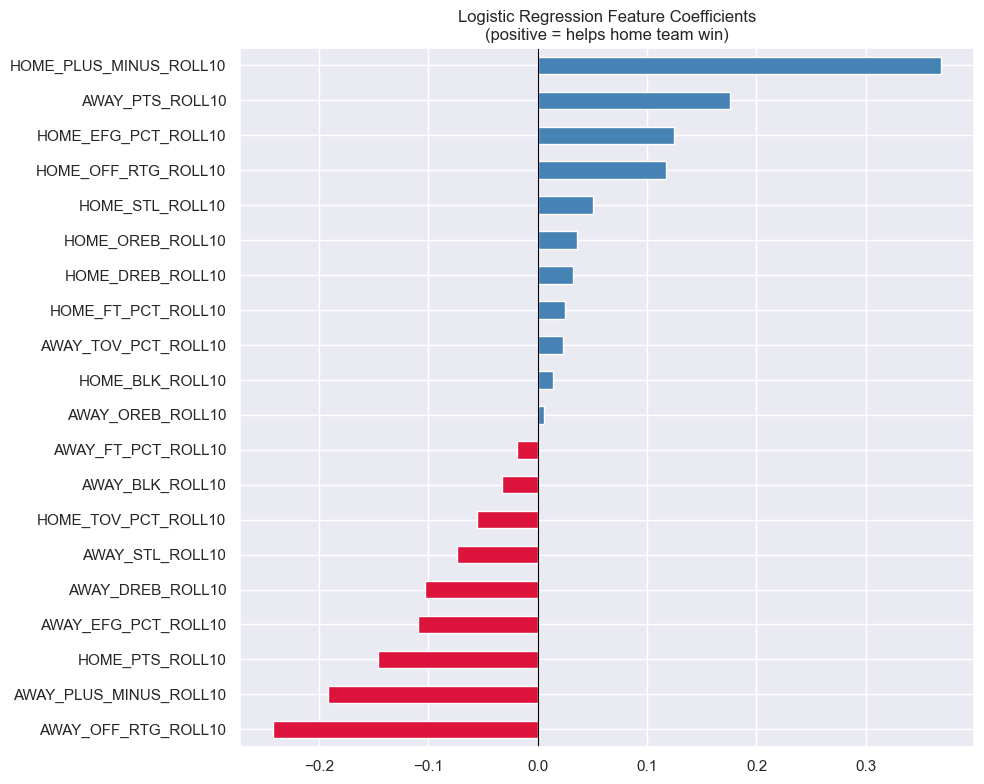

In [6]:
coefs = pd.Series(model.coef_[0], index=FEATURE_COLS).sort_values()

plt.figure(figsize=(10, 8))
colors = ["crimson" if c < 0 else "steelblue" for c in coefs]
coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Feature Coefficients\n(positive = helps home team win)")
plt.tight_layout()
plt.show()


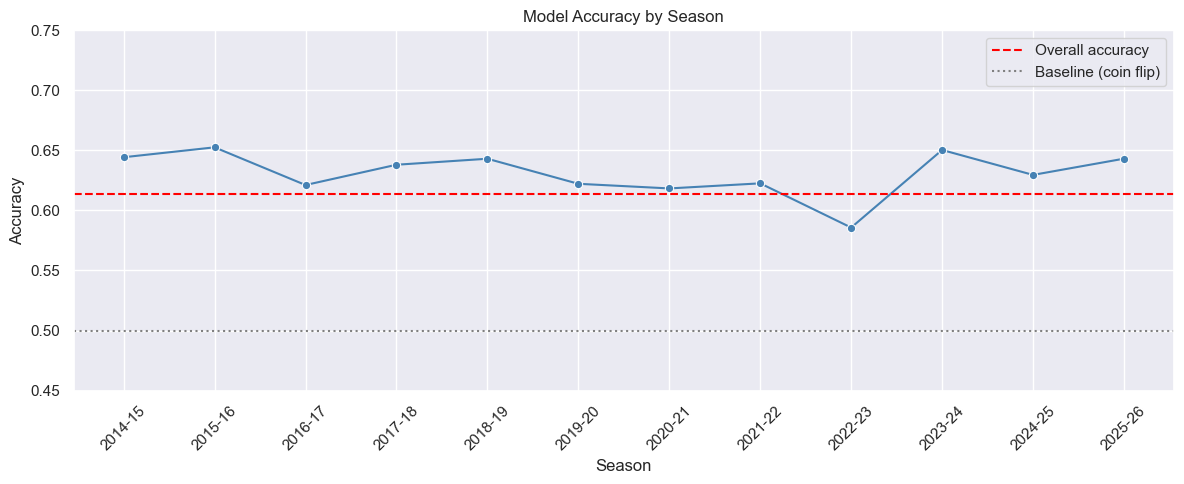

In [7]:
results = []
for season in sorted(df["HOME_SEASON"].unique()):
    subset = df[df["HOME_SEASON"] == season]
    X_s = subset[FEATURE_COLS].dropna()
    y_s = subset.loc[X_s.index, "TARGET"]
    if len(y_s) < 10:
        continue
    preds = model.predict(scaler.transform(X_s))
    acc = accuracy_score(y_s, preds)
    results.append({"Season": season, "Accuracy": acc})

results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 5))
sns.lineplot(data=results_df, x="Season", y="Accuracy", marker="o", color="steelblue")
plt.axhline(0.614, color="red", linestyle="--", label="Overall accuracy")
plt.axhline(0.5, color="gray", linestyle=":", label="Baseline (coin flip)")
plt.title("Model Accuracy by Season")
plt.xticks(rotation=45)
plt.ylim(0.45, 0.75)
plt.legend()
plt.tight_layout()
plt.show()

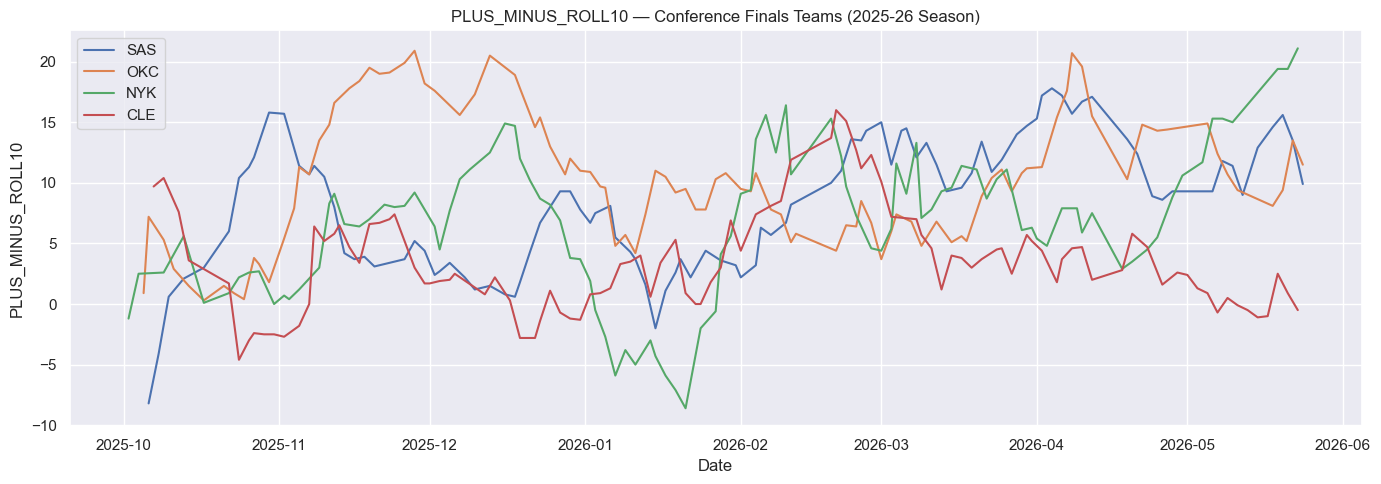

In [10]:
import sys
sys.path.append("..")
from src.clean_data import load_raw, add_basic_features, add_rolling_features

df_raw = load_raw("../data/games_raw.csv")
df_raw = add_basic_features(df_raw)
df_raw = add_rolling_features(df_raw)

teams  = ["SAS", "OKC", "NYK", "CLE"]
metric = "PLUS_MINUS_ROLL10"

plt.figure(figsize=(14, 5))
for team in teams:
    team_df = df_raw[df_raw["TEAM_ABBREVIATION"] == team].sort_values("GAME_DATE")
    team_df = team_df[team_df["GAME_DATE"] > "2025-10-01"]  
    plt.plot(team_df["GAME_DATE"], team_df[metric], label=team, linewidth=1.5)

plt.title(f"{metric} — Conference Finals Teams (2025-26 Season)")
plt.xlabel("Date")
plt.ylabel(metric)
plt.legend()
plt.tight_layout()
plt.show()